In [45]:
import pandas as pd
import numpy as np

In [61]:
df = pd.read_csv("final_dataset2.csv")
df

,text,label
0,subject office maintenance thanks for your hel...,0
1,hello your profile has been locked use the sec...,1
2,hi there congratulations you are the winner of...,1
3,attention this is the fraud prevention account...,1
4,notice your profile has been restricted use th...,1
...,...,...
30207,raquel s casino inc is awarding a cruise to a ...,1
30208,the list owner of kiddin has invited you to jo...,1
30209,judging from the return post i must have sound...,0
30210,gotcha there are two separate fallacies in the...,0


In [62]:
df.isnull().sum()

,0
text,1
label,0


In [63]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.isnull().sum()

,0
text,0
label,0


In [64]:
df

,text,label
0,subject office maintenance thanks for your hel...,0
1,hello your profile has been locked use the sec...,1
2,hi there congratulations you are the winner of...,1
3,attention this is the fraud prevention account...,1
4,notice your profile has been restricted use th...,1
...,...,...
30206,raquel s casino inc is awarding a cruise to a ...,1
30207,the list owner of kiddin has invited you to jo...,1
30208,judging from the return post i must have sound...,0
30209,gotcha there are two separate fallacies in the...,0


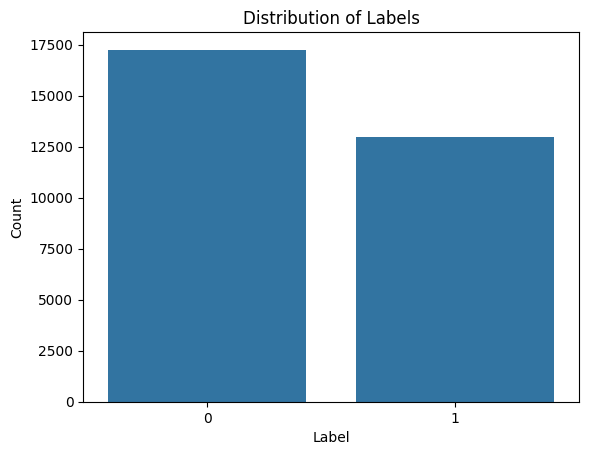

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [66]:
df['label'].value_counts()

,count
label,
0,17250
1,12961


In [67]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score
from torch.optim.lr_scheduler import ExponentialLR
from transformers import BertModel, AutoTokenizer
from tqdm.notebook import tqdm

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [69]:
transformer_name = "bert-base-uncased"

In [70]:
class EmailDataset(Dataset):
    def __init__(self, df):
        self.emails = df['text']
        self.labels = df['label']

    def __len__(self):
        return len(self.emails)

    def __getitem__(self, idx):
        email = self.emails[idx]
        label = self.labels[idx]
        return email, label

dataset = EmailDataset(df)
print(f"Dataset initialized with {len(dataset)} samples.")

Dataset initialized with 30211 samples.


In [71]:
from torch.utils.data import random_split

total = len(dataset)
test_size = int(total * 0.1)
val_size = int(total * 0.2)
train_size = total - val_size - test_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Train: 21148, Val: 6042, Test: 3021


In [72]:
bert_tokenizer = AutoTokenizer.from_pretrained(transformer_name)

def collate_fn(batch):
    emails = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    # Process texts using the BERT tokenizer
    encoded_texts = bert_tokenizer(
        emails,
        padding=True,
        truncation=True,
        max_length=128, # Adjust max_length as needed for the BERT model
        return_tensors='pt'
    )
    input_ids = encoded_texts['input_ids']
    attention_mask = encoded_texts['attention_mask']

    # Process labels
    labels = torch.tensor(labels, dtype=torch.long) # Using long for classification labels

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [73]:
class TextClassifier(nn.Module):
    def __init__(self):
        super(TextClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(transformer_name, use_safetensors=True)
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        return self.classifier(pooled_output)

In [74]:
model = TextClassifier().to(device)
LR = 2e-5
epochs = 20
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ExponentialLR(optimizer, gamma=0.9)
pos_weight = torch.tensor([17251/12961]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [75]:
best_val_f1 = 0
patience = 5
patience_counter = 0
threshold = 0.5

for epoch in range(epochs):
    # Training
    model.train()
    total, correct, train_loss = 0, 0, 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Training'):
        optimizer.zero_grad()
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['labels'].float().unsqueeze(1).to(device)

        out = model(ids, mask)
        loss = criterion(out, lbl)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(out) >= threshold).float()
        correct += (preds == lbl).sum().item()
        total   += lbl.size(0)

    train_acc  = correct / total
    train_loss = train_loss / len(train_loader)
    scheduler.step()

    # Validation
    model.eval()
    total, correct, val_loss = 0, 0, 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'      - Validation'):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['labels'].float().unsqueeze(1).to(device)

            out = model(ids, mask)
            loss = criterion(out, lbl)
            val_loss += loss.item()

            preds = (torch.sigmoid(out) >= threshold).float()
            correct += (preds == lbl).sum().item()
            total   += lbl.size(0)
            all_preds.extend(preds.cpu().int().numpy().flatten())
            all_targets.extend(lbl.cpu().int().numpy().flatten())

    val_acc  = correct / total
    val_loss = val_loss / len(val_loader)
    val_macro_f1 = f1_score(all_targets, all_preds, average='macro')

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(classification_report(all_targets, all_preds, target_names=["not phishing", "phishing"]))

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
        print(f"  ✓ Best model saved (val_macro_f1={val_macro_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/20 - Training:   0%|          | 0/661 [00:00<?, ?it/s]

      - Validation:   0%|          | 0/189 [00:00<?, ?it/s]


Epoch 1/20
  Train Loss: 0.1435 | Train Acc: 0.9573
  Val   Loss: 0.0402 | Val   Acc: 0.9886
              precision    recall  f1-score   support

not phishing       0.99      0.99      0.99      3461
    phishing       0.99      0.99      0.99      2581

    accuracy                           0.99      6042
   macro avg       0.99      0.99      0.99      6042
weighted avg       0.99      0.99      0.99      6042

  ✓ Best model saved (val_macro_f1=0.9883)


Epoch 2/20 - Training:   0%|          | 0/661 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [76]:
model.load_state_dict(torch.load("best_model.pt", weights_only=False))
model.eval()

total, correct = 0, 0
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['labels'].float().unsqueeze(1).to(device)

        out   = model(ids, mask)
        probs = torch.sigmoid(out)
        preds = (probs >= threshold).float()

        correct += (preds == lbl).sum().item()
        total   += lbl.size(0)
        all_preds.extend(preds.cpu().int().numpy().flatten())
        all_targets.extend(lbl.cpu().int().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())

test_acc   = correct / total
test_auroc = roc_auc_score(all_targets, all_probs)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test AUROC:    {test_auroc:.4f}")
print(classification_report(all_targets, all_preds, target_names=["not phishing", "phishing"]))

Testing:   0%|          | 0/95 [00:00<?, ?it/s]


Test Accuracy: 0.9907
Test AUROC:    0.9995
              precision    recall  f1-score   support

not phishing       0.99      0.99      0.99      1730
    phishing       0.99      0.99      0.99      1291

    accuracy                           0.99      3021
   macro avg       0.99      0.99      0.99      3021
weighted avg       0.99      0.99      0.99      3021

